In [7]:
# Libraries
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import shap
from sklearn.inspection import permutation_importance
from sklearn.inspection import PartialDependenceDisplay
from lightgbm import LGBMRegressor
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive

shap.initjs()

In [6]:
# Download data
# ==============================================================================
data = fetch_dataset(name="vic_electricity")
data.head(3)

╭──────────────────────────── vic_electricity ─────────────────────────────╮
│ Description:                                                             │
│ Half-hourly electricity demand for Victoria, Australia                   │
│                                                                          │
│ Source:                                                                  │
│ O'Hara-Wild M, Hyndman R, Wang E, Godahewa R (2022).tsibbledata: Diverse │
│ Datasets for 'tsibble'. https://tsibbledata.tidyverts.org/,              │
│ https://github.com/tidyverts/tsibbledata/.                               │
│ https://tsibbledata.tidyverts.org/reference/vic_elec.html                │
│                                                                          │
│ URL:                                                                     │
│ https://raw.githubusercontent.com/skforecast/skforecast-                 │
│ datasets/main/data/vic_electricity.csv                                   │
│                                                                          │
│ Shape: 52608 rows x 4 columns                                            │
╰──────────────────────────────────────────────────────────────────────────╯

,Demand,Temperature,Date,Holiday
Time,,,,
2011-12-31 13:00:00,4382.825174,21.40,2012-01-01,True
2011-12-31 13:30:00,4263.365526,21.05,2012-01-01,True
2011-12-31 14:00:00,4048.966046,20.70,2012-01-01,True


In [9]:
# Aggregation to daily frequency
# ==============================================================================
data = data.resample('D').agg({'Demand': 'sum', 'Temperature': 'mean'})
data.head(3)

,Demand,Temperature
Time,,
2011-12-31,82531.745918,21.047727
2012-01-01,227778.257304,26.578125
2012-01-02,275490.988882,31.751042


In [10]:
# Split train-test
# ==============================================================================
data_train = data.loc[: '2014-12-21']
data_test  = data.loc['2014-12-22':]

print(f"Tanggal train : {data_train.index.min()} — {data_train.index.max()}")
print(f"Tanggal test  : {data_test.index.min()} — {data_test.index.max()}")
print(f"Shape train   : {data_train.shape}")
print(f"Shape test    : {data_test.shape}")

Tanggal train : 2011-12-31 00:00:00 — 2014-12-21 00:00:00
Tanggal test  : 2014-12-22 00:00:00 — 2014-12-31 00:00:00
Shape train   : (1087, 2)
Shape test    : (10, 2)


In [11]:
# Create a recursive multi-step forecaster (ForecasterRecursive)
# ==============================================================================
forecaster = ForecasterRecursive(
    estimator = LGBMRegressor(random_state=123, verbose=-1),
    lags      = 7
)

forecaster.fit(
    y    = data_train['Demand'],
    exog = data_train['Temperature']
)

forecaster

=================== 
ForecasterRecursive 
=================== 
Estimator: LGBMRegressor 
Lags: [1 2 3 4 5 6 7] 
Window features: None 
Window size: 7 
Series name: Demand 
Exogenous included: True 
Exogenous names: Temperature 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('2011-12-31 00:00:00'), Timestamp('2014-12-21 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Day> 
Estimator parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.1, 'max_depth': -1,
    'min_child_samples': 20, 'min_child_weight': 0.001, 'min_split_gain': 0.0,
    'n_estimators': 100, 'n_jobs': None, 'num_leaves': 31, 'objective': None,
    'random_state': 123, 'reg_alpha': 0.0, 'reg_lambda': 0.0, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-06-11 15:11:32 
Last fit date: 2026-06-11 15:11:35 
Skforecast version: 0.22.0 
Python version: 3.12.5 
Forecaster id: None

In [12]:
# Feature importances
# ==============================================================================
feature_importances = forecaster.get_feature_importances()
feature_importances

,feature,importance
7,Temperature,570
0,lag_1,470
2,lag_3,387
1,lag_2,362
6,lag_7,325
5,lag_6,313
4,lag_5,298
3,lag_4,275


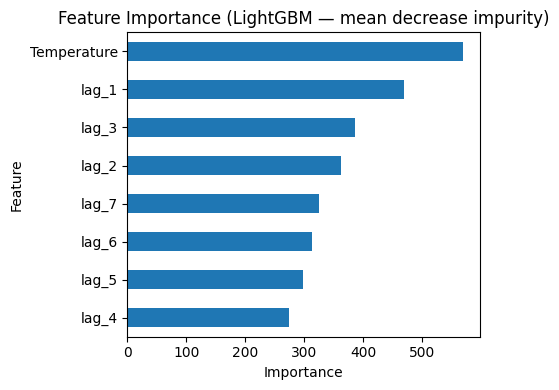

In [13]:
# Plot feature importances
# ==============================================================================
fig, ax = plt.subplots(figsize=(5, 4))
feature_importances.sort_values('importance', ascending=True).plot(
    x      = 'feature',
    y      = 'importance',
    kind   = 'barh',
    ax     = ax,
    legend = False
)
ax.set_title('Feature Importance (LightGBM — mean decrease impurity)')
ax.set_xlabel('Importance')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

In [14]:
# Training matrices used by the forecaster to fit the internal regressor
# ==============================================================================
X_train, y_train = forecaster.create_train_X_y(
    y    = data_train['Demand'],
    exog = data_train['Temperature']
)

display(X_train.head(3))  # Features (lag_1 ... lag_7, Temperature)
display(y_train.head(3))  # Target

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
Time,,,,,,,,
2012-01-07,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,82531.745918,24.098958
2012-01-08,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,20.223958
2012-01-09,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,19.161458


Time
2012-01-07    200693.270298
2012-01-08    200061.614738
2012-01-09    216201.836844
Freq: D, Name: y, dtype: float64

In [15]:
# Permutation importance
# ==============================================================================
result = permutation_importance(
    estimator    = forecaster.estimator,
    X            = X_train,
    y            = y_train,
    n_repeats    = 10,
    random_state = 123,
    n_jobs       = -1
)

permutation_imp_df = pd.DataFrame({
    'feature'         : X_train.columns,
    'importance_mean' : result.importances_mean,
    'importance_std'  : result.importances_std
}).sort_values('importance_mean', ascending=False)

permutation_imp_df

,feature,importance_mean,importance_std
0,lag_1,0.627840,0.026905
7,Temperature,0.411182,0.016031
6,lag_7,0.189094,0.006811
1,lag_2,0.109668,0.004352
5,lag_6,0.077652,0.002949
2,lag_3,0.039407,0.001626
4,lag_5,0.030589,0.001519
3,lag_4,0.024034,0.001446


C:\Users\hp\AppData\Local\Temp\ipykernel_13804\976834887.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


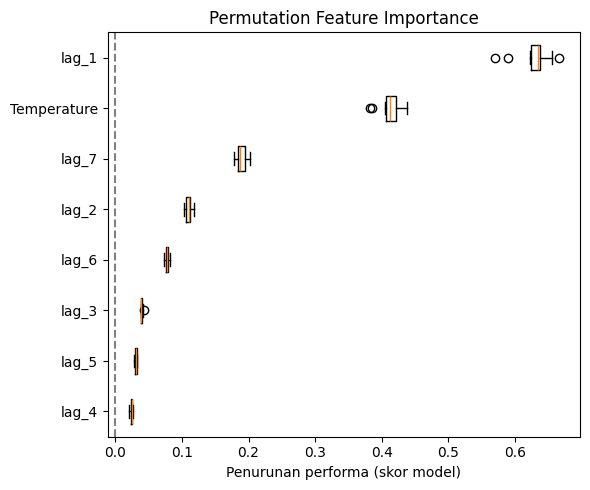

In [16]:
# Plot permutation importance
# ==============================================================================
sorted_idx = result.importances_mean.argsort()

fig, ax = plt.subplots(figsize=(6, 5))
ax.boxplot(
    result.importances[sorted_idx].T,
    vert   = False,
    labels = X_train.columns[sorted_idx]
)
ax.set_title('Permutation Feature Importance')
ax.set_xlabel('Penurunan performa (skor model)')
ax.axvline(x=0, color='grey', linestyle='--')
plt.tight_layout()
plt.show()

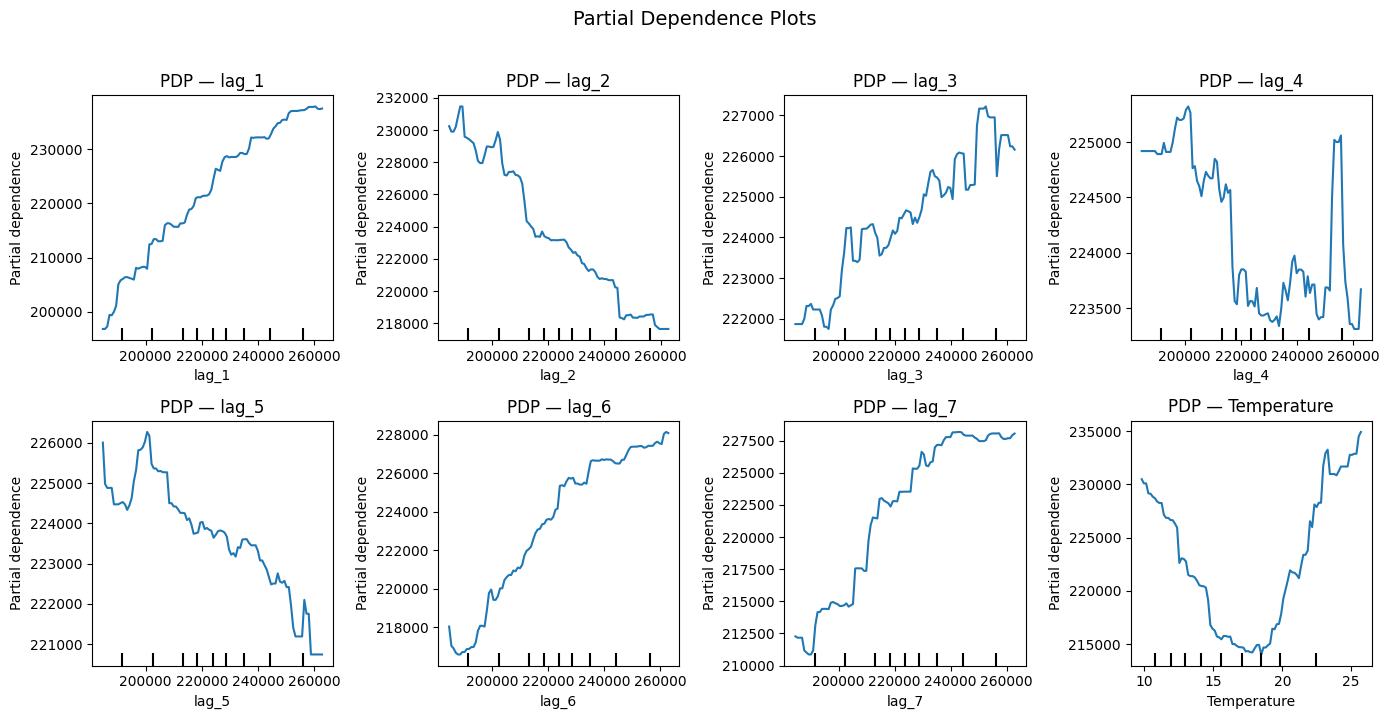

In [17]:
# Partial Dependence Plots
# ==============================================================================
features_to_plot = ['lag_1', 'lag_2', 'lag_3', 'lag_4',
                    'lag_5', 'lag_6', 'lag_7', 'Temperature']

fig, axes = plt.subplots(
    nrows   = 2,
    ncols   = 4,
    figsize = (14, 7),
    sharey  = False
)
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    PartialDependenceDisplay.from_estimator(
        estimator  = forecaster.estimator,
        X          = X_train,
        features   = [feature],
        kind       = 'average',
        ax         = axes[i]
    )
    axes[i].set_title(f'PDP — {feature}')

plt.suptitle('Partial Dependence Plots', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [18]:
# Training matrices used by the forecaster to fit the internal regressor
# ==============================================================================
X_train, y_train = forecaster.create_train_X_y(
    y    = data_train['Demand'],
    exog = data_train['Temperature']
)

display(X_train.head(3))
display(y_train.head(3))

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
Time,,,,,,,,
2012-01-07,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,82531.745918,24.098958
2012-01-08,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,227778.257304,20.223958
2012-01-09,200061.614738,200693.270298,205338.714620,211066.426550,213792.376946,258955.329422,275490.988882,19.161458


Time
2012-01-07    200693.270298
2012-01-08    200061.614738
2012-01-09    216201.836844
Freq: D, Name: y, dtype: float64

In [19]:
# Create SHAP explainer
# ==============================================================================
explainer   = shap.TreeExplainer(forecaster.estimator)
shap_values = explainer.shap_values(X_train)

print(f"Shape SHAP values  : {shap_values.shape}")
print(f"Expected value     : {explainer.expected_value:.2f}")
print(f"Shape X_train      : {X_train.shape}")

Shape SHAP values  : (1080, 8)
Expected value     : 224215.91
Shape X_train      : (1080, 8)


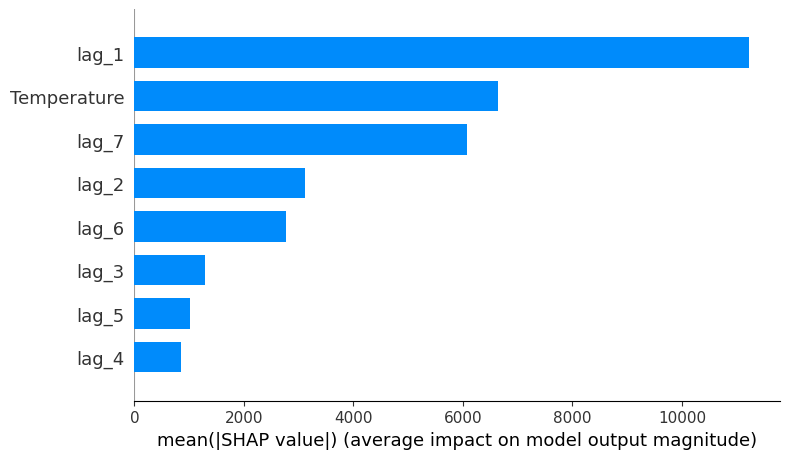

In [20]:
# SHAP summary plot — bar (global feature importance)
# ==============================================================================
shap.summary_plot(
    shap_values,
    X_train,
    plot_type = 'bar',
    show      = True
)

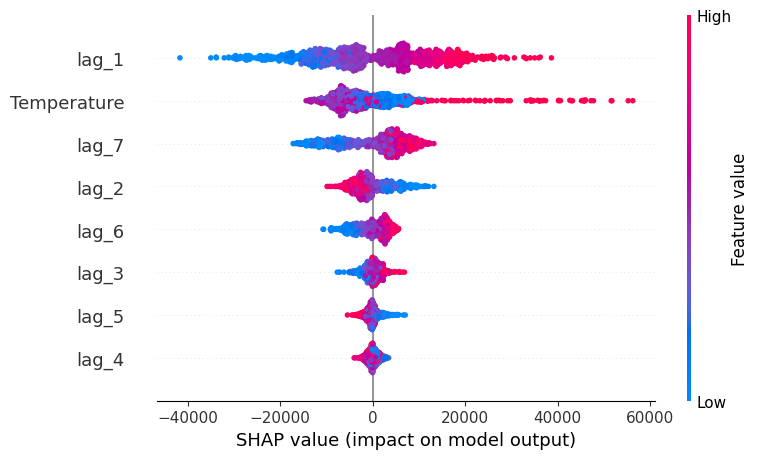

In [21]:
# SHAP summary plot — dot (distribusi kontribusi per observasi)
# ==============================================================================
shap.summary_plot(
    shap_values,
    X_train,
    show = True
)

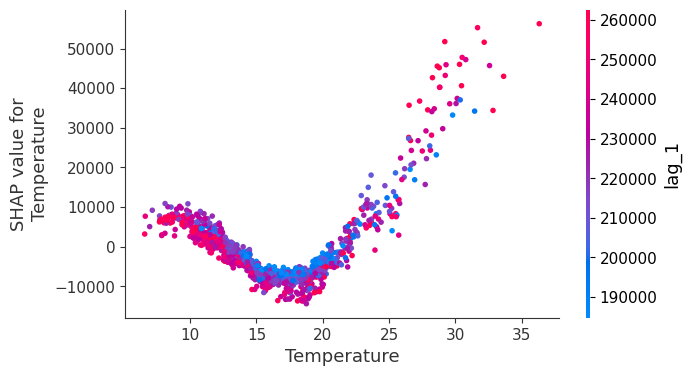

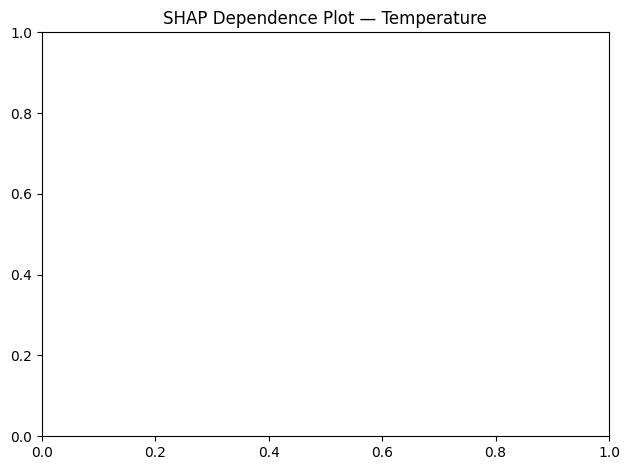

In [22]:
# SHAP dependence plot untuk fitur Temperature
# ==============================================================================
fig, ax = plt.subplots(figsize=(7, 4))
shap.dependence_plot(
    "Temperature",
    shap_values,
    X_train,
    ax = ax
)
plt.title('SHAP Dependence Plot — Temperature')
plt.tight_layout()
plt.show()

In [23]:
# SHAP force plot — penjelasan untuk satu observasi (observasi pertama)
# ==============================================================================
shap.force_plot(
    base_value  = explainer.expected_value,
    shap_values = shap_values[0, :],
    features    = X_train.iloc[0, :]
)

In [24]:
# ==============================================================================
shap.force_plot(explainer.expected_value, shap_values[:200, :], X_train.iloc[:200, :])

In [25]:
# Create input matrix for predict method
# ==============================================================================
X_predict = forecaster.create_predict_X(
    steps = 10,
    exog  = data_test['Temperature']
)

X_predict

,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,Temperature
2014-12-22,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,231923.044018,22.950000
2014-12-23,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,226093.767670,18.829167
2014-12-24,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,215507.677076,18.312500
2014-12-25,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,214934.022460,16.933333
2014-12-26,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,197129.766534,16.429167
2014-12-27,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,186486.896670,18.189583
2014-12-28,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,216483.631690,24.539583
2014-12-29,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,241514.532543,17.677083
2014-12-30,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,226165.936559,17.391667
2014-12-31,219103.891733,223112.716406,222766.340659,195623.591810,184885.145832,209260.948991,220506.468700,21.034615


In [26]:
# SHAP values untuk data prediksi
# ==============================================================================
shap_values_pred = explainer.shap_values(X_predict)

print(f"Shape SHAP values prediksi : {shap_values_pred.shape}")

Shape SHAP values prediksi : (10, 8)


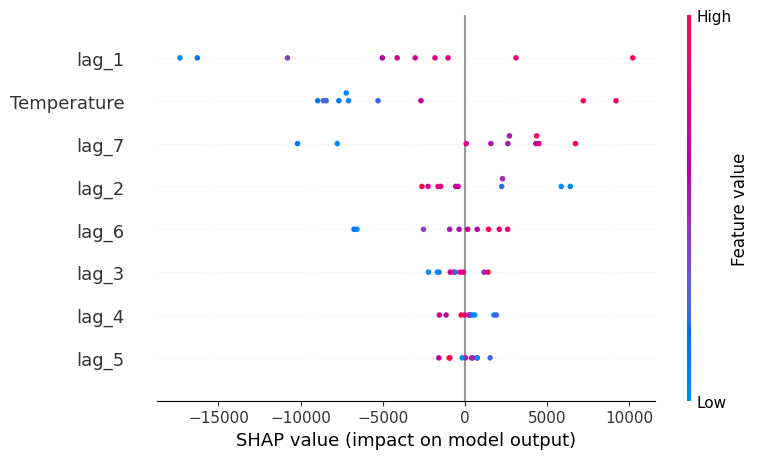

In [27]:
# SHAP summary plot untuk data prediksi
# ==============================================================================
shap.summary_plot(
    shap_values_pred,
    X_predict,
    show = True
)

In [28]:
# SHAP force plot untuk langkah prediksi pertama
# ==============================================================================
shap.force_plot(
    base_value  = explainer.expected_value,
    shap_values = shap_values_pred[0, :],
    features    = X_predict.iloc[0, :]
)